In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/govindaramsriram/energy-consumption-dataset-linear-regression/train_energy_data.csv
/kaggle/input/datasets/govindaramsriram/energy-consumption-dataset-linear-regression/test_energy_data.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df=pd.read_csv("/kaggle/input/datasets/govindaramsriram/energy-consumption-dataset-linear-regression/train_energy_data.csv")
df

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
...,...,...,...,...,...,...,...
995,Residential,14419,68,44,23.95,Weekend,3661.21
996,Industrial,12194,7,22,14.67,Weekend,3546.34
997,Commercial,39562,88,20,32.18,Weekday,5147.21
998,Residential,8348,67,37,16.48,Weekend,3244.98


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Square Footage,1000.0,25462.38800,14294.554000,560.00,13169.7500,25477.000,37446.25,49997.00
Number of Occupants,1000.0,48.37200,29.061972,1.00,22.0000,47.000,73.25,99.00
Appliances Used,1000.0,25.60600,14.105166,1.00,13.0000,26.000,38.00,49.00
Average Temperature,1000.0,22.61139,7.139943,10.05,16.4750,22.815,28.85,34.99
Energy Consumption,1000.0,4166.25257,933.313064,1683.95,3509.4825,4175.730,4863.85,6530.60


In [6]:
df.isna().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [7]:
print("Building Type:")
print(df["Building Type"].value_counts())

print("\nDay of Week:")
print(df["Day of Week"].value_counts())

Building Type:
Building Type
Residential    347
Commercial     336
Industrial     317
Name: count, dtype: int64

Day of Week:
Day of Week
Weekday    507
Weekend    493
Name: count, dtype: int64


In [8]:
df.corr(numeric_only=True)

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
Square Footage,1.000000,0.033379,-0.013478,0.027273,0.774873
Number of Occupants,0.033379,1.000000,0.023646,0.014122,0.354485
Appliances Used,-0.013478,0.023646,1.000000,-0.062870,0.312792
Average Temperature,0.027273,0.014122,-0.062870,1.000000,-0.034487
Energy Consumption,0.774873,0.354485,0.312792,-0.034487,1.000000


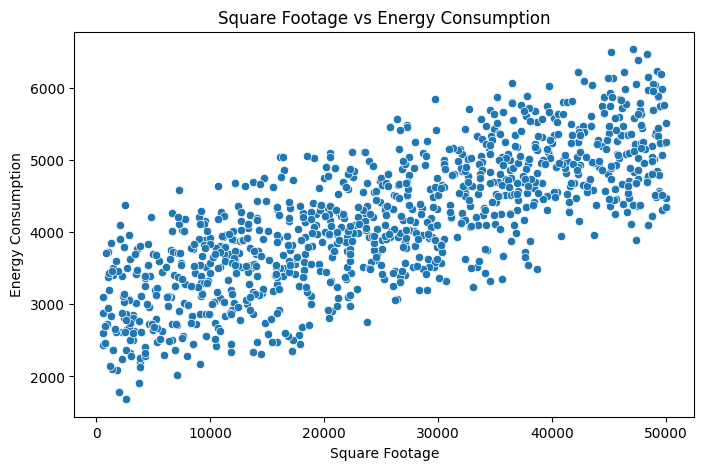

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Square Footage", y="Energy Consumption")
plt.title("Square Footage vs Energy Consumption")
plt.show()

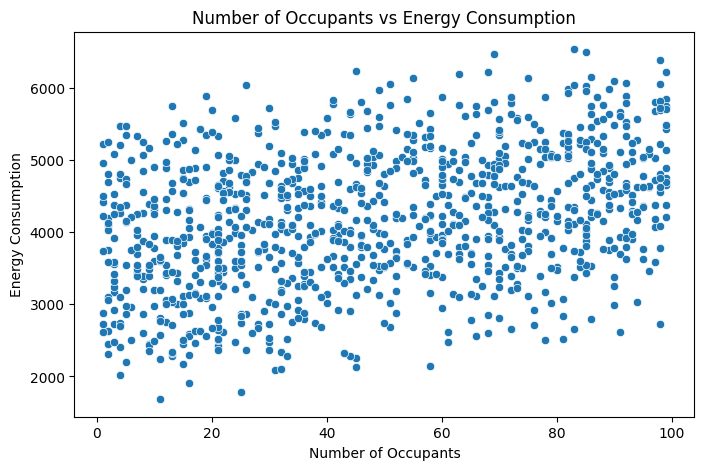

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Number of Occupants", y="Energy Consumption")
plt.title("Number of Occupants vs Energy Consumption")
plt.show()

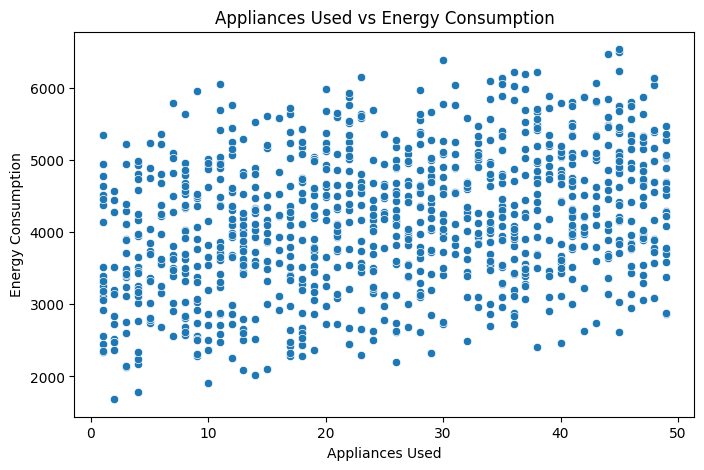

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Appliances Used", y="Energy Consumption")
plt.title("Appliances Used vs Energy Consumption")
plt.show()

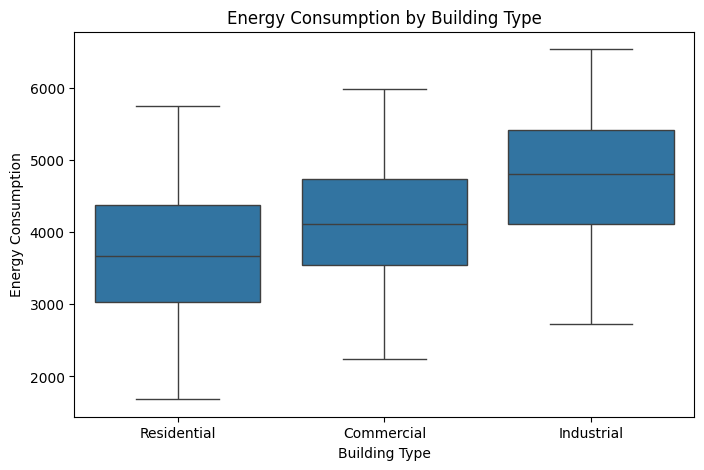

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Building Type", y="Energy Consumption")
plt.title("Energy Consumption by Building Type")
plt.show()

In [13]:
X = df.drop("Energy Consumption", axis=1)
y = df["Energy Consumption"]

In [14]:
X = pd.get_dummies(X, columns=["Building Type", "Day of Week"], drop_first=True)

In [15]:
X.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,7063,76,10,29.84,False,True,False
1,44372,66,45,16.72,False,False,False
2,19255,37,17,14.30,True,False,True
3,13265,14,41,32.82,False,True,False
4,13375,26,18,11.92,False,False,False


In [16]:
X.shape

(1000, 7)

In [17]:
model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [18]:
y_pred = model.predict(X)

print("R² Score:", r2_score(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))

R² Score: 0.9999999997858984
MAE: 0.011572626600262538
MSE: 0.00018631165968504862


In [19]:
test_df = pd.read_csv("/kaggle/input/datasets/govindaramsriram/energy-consumption-dataset-linear-regression/test_energy_data.csv")

In [20]:
X_test = test_df.drop("Energy Consumption", axis=1)
y_test = test_df["Energy Consumption"]

In [21]:
X_test = pd.get_dummies(
    X_test,
    columns=["Building Type", "Day of Week"],
    drop_first=True
)

In [22]:
X_test = X_test.reindex(columns=X.columns, fill_value=0)

In [23]:
y_test_pred = model.predict(X_test)

In [24]:
print("Test R² Score:", r2_score(y_test, y_test_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Test R² Score: 0.9999999997063025
Test MAE: 0.012161901154095177
Test MSE: 0.00020154241156461938


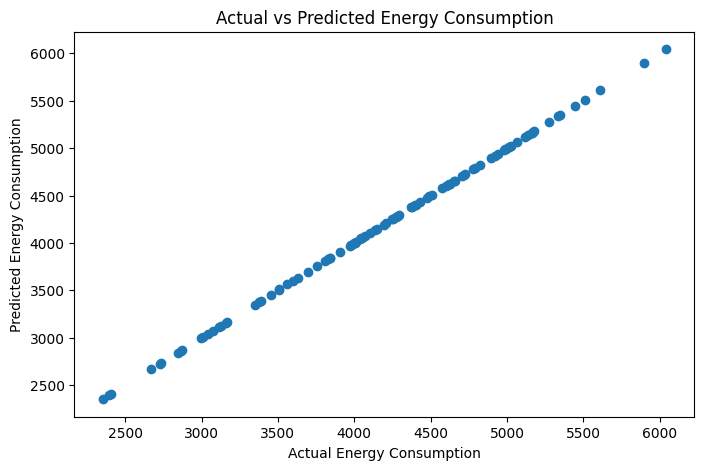

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_test_pred)

plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")

plt.show()

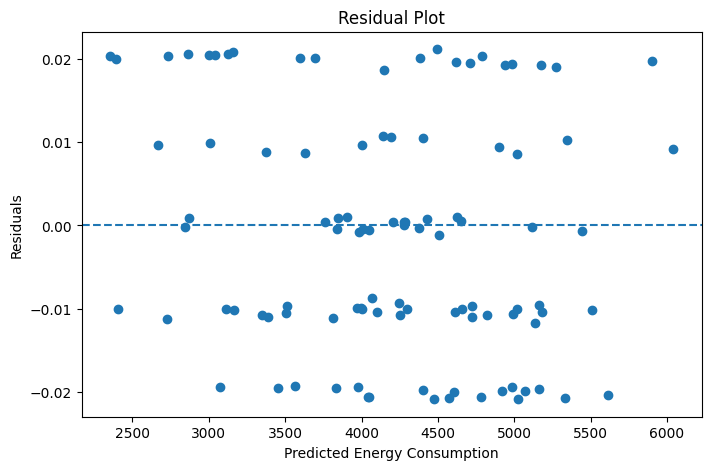

In [26]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_test_pred, residuals)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Energy Consumption")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [27]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,Building Type_Industrial,500.000492
2,Appliances Used,20.000020
1,Number of Occupants,10.000003
0,Square Footage,0.050000
3,Average Temperature,-5.000047
6,Day of Week_Weekend,-50.000770
5,Building Type_Residential,-500.000189


In [28]:
print("Intercept:", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

Intercept: 2050.00113769775
Square Footage: 0.0500
Number of Occupants: 10.0000
Appliances Used: 20.0000
Average Temperature: -5.0000
Building Type_Industrial: 500.0005
Building Type_Residential: -500.0002
Day of Week_Weekend: -50.0008


In [29]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

comparison.head(10)

,Actual,Predicted
0,2865.57,2865.549425
1,4283.80,4283.799561
2,5067.83,5067.849874
3,4624.30,4624.298951
4,4820.59,4820.600787
5,5026.23,5026.250860
6,4404.56,4404.549512
7,2394.37,2394.350021
8,3969.09,3969.099913
9,5136.69,5136.701721
